In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from torchvision.utils import save_image, make_grid
from torch.optim import Adam
import torch.nn.init as init

import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
# from matplotlib.cm import get_cmap

import copy
import seaborn as sns

from scipy.stats import norm
from sklearn.neighbors import KernelDensity, LocalOutlierFactor
from sklearn.decomposition import PCA

import tqdm
import pickle

# MI estimators
# from utils.estimators import *

In [3]:
def import_data(mode:list , num_policy:int , case:str, level:int=5):
    dataset = {key : [] for key in mode}
    for i in dataset.keys():   # sensor modality
        for policy in range(num_policy): # each run have 3 policies
            if case == "slope":
                dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}{str(level)}.npy" , allow_pickle=True).item())
                # dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}{str(level)}.npz" , allow_pickle=True))

            else:
                dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}.npy" , allow_pickle=True).item())
                # dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}.npz" , allow_pickle=True))

    # print(dataset)
    for key, value in dataset.items():
        dataset[key] = np.array(value)
    return dataset

In [4]:
NUM_POLICY = 5
# Hebb vs CPG
# mode=["full","vel_act", "pos_act", "pos_vel_act", "act_FC", "act_IMU_FC", "pos_act_IMU", "pos_act_FC", "vel_act_IMU", "vel_act_FC" , "CPG_RBF"]
# Hebb only
# mode=["full","vel_act", "pos_acvel
mode = ["vel",'pos_action','vel_action','pos_vel_action','vel_imu','pos_action_imu','vel_action_imu',
 'pos_vel_action_imu','vel_fc','action_fc','vel_action_fc','pos_vel_action_fc','vel_imu_fc',
 'pos_vel_imu_fc','action_imu_fc','vel_action_imu_fc','pos_vel_action_imu_fc']

flat        =   import_data(mode , NUM_POLICY , case="flat")
slope_10    =   import_data(mode , NUM_POLICY , case="slope",level=-10)
slope10     =   import_data(mode , NUM_POLICY , case="slope",level=10)

mass1000    =   import_data(mode , NUM_POLICY , case="mass" , level=1000)


# flat        =   import_data(mode , NUM_POLICY , case="flat")
rough       =   import_data(mode , NUM_POLICY , case="rough")
morph       =   import_data(mode , NUM_POLICY , case="morph")

slope_list      = [slope10 ,slope_10 ] # The 15 is slip so the result is shown in not significant way. [slope5 , slope10 , slope15 , slope_5 , slope_10 ,  slope_15]
slope_list_str  = ["slope10" , "slope_10"]


mass_list       = [mass1000] # [mass250 , mass500 , mass1000 , mass2000 , mass5000 , mass10000
mass_list_str   = ["mass1000"]
# [case:str][number_file:int][data/brain:str]

## Preprocess Data

In [5]:
def preprocess(selected_dataset , num_pol):
    performance = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}
    max_distance = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}
    avg_vel = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}

    for policy in range(num_pol):
        for case in selected_dataset.keys():
            reward = np.sum(selected_dataset[case][policy]["data"]['reward'], axis=0)
            performance[f"policy{policy}"][case] = reward

            max_pos_x = np.max(selected_dataset[case][policy]["data"]['pos_x'], axis=0)
            max_distance[f"policy{policy}"][case] = max_pos_x

            vel_x = selected_dataset[case][policy]["data"]['vel_b'][:,:,0]
            avg_vel[f"policy{policy}"][case] = np.mean(vel_x ,axis=0)
    return performance , max_distance , avg_vel

def preprocess_combined(selected_dataset, num_pol):
    """
    Combine values from ALL policies into one 'policy_all' per case.

    Returns:
        performance_all, max_distance_all, avg_vel_all
        # Each is a dict like:
        # {
        #   'policy_all': {
        #       <case_a>: np.ndarray(... concatenated from all policies ...),
        #       <case_b>: np.ndarray(...),
        #       ...
        #   }
        # }
    """
    cases = list(selected_dataset.keys())

    # Buckets (lists) to collect per-policy arrays before concatenating
    perf_bucket = {case: [] for case in cases}
    dist_bucket = {case: [] for case in cases}
    vel_bucket  = {case: [] for case in cases}

    for policy in range(num_pol):
        for case in cases:
            # data = selected_dataset[case][policy]["data"]
            data = selected_dataset[case][policy]
            # print(case , data.keys())
            # 1) reward sum over time -> shape (..., ?) then flatten along new axis 0
            # print(data.keys())
            reward = np.sum(data["reward"], axis=0)
            perf_bucket[case].append(np.ravel(reward))

            # 2) max pos_x over time
            max_pos_x = np.max(data["pos_x"], axis=0)
            dist_bucket[case].append(np.ravel(max_pos_x))

            # 3) avg vel_x over time (take x component from vel_b[..., 0])
            vel_x = data["vel_b"][:, :, 0]
            avg_vel_x = np.mean(vel_x, axis=0)
            vel_bucket[case].append(np.ravel(avg_vel_x))

    # Concatenate across all policies so each case has one long vector
    performance_all = {"policy": {case: np.concatenate(perf_bucket[case], axis=0) if len(perf_bucket[case]) else np.array([]) for case in cases}}
    max_distance_all = {"policy": {case: np.concatenate(dist_bucket[case], axis=0) if len(dist_bucket[case]) else np.array([]) for case in cases}}
    avg_vel_all = {"policy": {case: np.concatenate(vel_bucket[case], axis=0) if len(vel_bucket[case]) else np.array([]) for case in cases}}

    return performance_all, max_distance_all, avg_vel_all

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb


def _pastel_colors(n):
    """Generate n pastel-ish colors by blending tab10 with white."""
    base = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    ]
    blend = []
    for i in range(n):
        r, g, b = to_rgb(base[i % len(base)])
        blend.append((0.7 + 0.3 * r, 0.7 + 0.3 * g, 0.7 + 0.3 * b))
    return blend


def plot_case_violinplot(
    metric_all: dict,
    policy_key: str = "policy",
    title: str = "Distribution by Case",
    ylabel: str = "",
    ylim: list = [0, 5],
    rotate_xticks: int = 30,
    savepath: str | None = None,
    show: bool = True,
    # --- pastel bodies ---
    pastel: bool = True,
    pastel_alpha: float = 0.9,
    # --- jittered points ---
    show_points: bool = True,
    jitter: float = 0.08,
    point_size: float = 8,
    point_alpha: float = 0.6,
    rng_seed: int | None = None,
):
    """
    Plot one pastel-filled violin per case and overlay jittered points.

    Parameters
    ----------
    metric_all : dict
        { policy_key: { case_name: np.ndarray, ... } }
    policy_key : str
        Which top-level key to use from metric_all.

    Returns
    -------
    (fig, ax)
    """
    if policy_key not in metric_all:
        raise KeyError(
            f"Expected key '{policy_key}' in metric_all. "
            f"Got keys: {list(metric_all.keys())}"
        )

    case_map = metric_all[policy_key]
    cases, data = [], []
    for case, arr in case_map.items():
        arr = np.asarray(arr)
        if arr.size == 0:
            continue
        cases.append(case)
        data.append(arr)

    if len(data) == 0:
        raise ValueError("No non-empty case arrays found to plot.")

    rng = np.random.default_rng(rng_seed)
    colors = _pastel_colors(len(data))
    fig, ax = plt.subplots(figsize=(10, 5))

    bp = ax.violinplot(
        data,
        showmeans=True,
        showmedians=True,
    )

    # Pastel fill — violinplot returns bp["bodies"], not bp["boxes"]
    if pastel:
        for body, c in zip(bp["bodies"], colors):
            body.set_facecolor(c)
            body.set_edgecolor("black")
            body.set_alpha(pastel_alpha)
            body.set_linewidth(1.0)

    # Style the mean and median lines
    bp["cmeans"].set_color("black")
    bp["cmeans"].set_linewidth(1.4)
    bp["cmedians"].set_color("dimgray")
    bp["cmedians"].set_linewidth(1.0)
    bp["cbars"].set_linewidth(0.8)
    bp["cmins"].set_linewidth(0.8)
    bp["cmaxes"].set_linewidth(0.8)

    # Jittered points overlay
    if show_points:
        clip_half_width = 0.35
        for i, arr in enumerate(data, start=1):
            xj = rng.normal(i, jitter, size=arr.size)
            xj = np.clip(xj, i - clip_half_width, i + clip_half_width)
            c = colors[i - 1] if pastel else None
            # darken the pastel color slightly for the points so they stand out
            if c is not None:
                r, g, b = c
                c = (max(0, r - 0.25), max(0, g - 0.25), max(0, b - 0.25))
            ax.scatter(xj, arr, s=point_size, alpha=point_alpha,
                       color=c, edgecolors="none", zorder=3)

    # Mean / median annotations to the right of each violin
    for i, arr in enumerate(data, start=1):
        mean_val = arr.mean()
        median_val = np.median(arr)
        ax.annotate(f"μ={mean_val:.3f}", xy=(i, mean_val),
                    xytext=(8, 0), textcoords="offset points",
                    ha="left", va="center", fontsize=10,
                    color="black", fontweight="bold")
        ax.annotate(f"m={median_val:.3f}", xy=(i, median_val),
                    xytext=(8, 0), textcoords="offset points",
                    ha="left", va="center", fontsize=10,
                    color="dimgray")

    # x-tick labels (violinplot doesn't accept tick_labels directly)
    ax.set_xticks(range(1, len(cases) + 1))
    ax.set_xticklabels(cases)

    # Axes formatting
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=13)
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    if rotate_xticks:
        for tick in ax.get_xticklabels():
            tick.set_rotation(rotate_xticks)
            tick.set_ha("right")

    # Mean annotation just below the top of the plot
    y_max = ax.get_ylim()[1]
    y_range = y_max - ax.get_ylim()[0]
    for i, arr in enumerate(data, start=1):
        ax.text(i, y_max - 0.05 * y_range, f"μ={arr.mean():.3f}",
                ha="center", va="top", fontsize=12)

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

In [8]:
num_pol = 5
max_distance = {}
reward = {}
avg_vel = {}

# Get performance criteria
# Slope data
for idx , slope_data in enumerate(slope_list):
    reward[slope_list_str[idx]] , max_distance[slope_list_str[idx]] , avg_vel[slope_list_str[idx]]= preprocess_combined(selected_dataset=slope_data , num_pol=num_pol)

# Mass data
for idx , mass_data in enumerate(mass_list):
    reward[mass_list_str[idx]] , max_distance[mass_list_str[idx]] , avg_vel[mass_list_str[idx]]= preprocess_combined(selected_dataset=mass_data , num_pol=num_pol)

reward["flat"] , max_distance["flat"] , avg_vel["flat"] = preprocess_combined(selected_dataset=flat , num_pol=num_pol)
reward["rough"] , max_distance["rough"] , avg_vel["rough"] = preprocess_combined(selected_dataset=rough , num_pol=num_pol)
reward["morph"] , max_distance["morph"] , avg_vel["morph"] = preprocess_combined(selected_dataset=morph , num_pol=num_pol)





In [9]:
rough["vel"][4].keys()

dict_keys(['state', 'action', 'vel', 'action_lowpass', 'pos_x', 'pos_y', 'yaw', 'fc', 'reward', 'dof_vel', 'torque', 'vel_w', 'vel_b', 'dof_pos', 'dof_pos_scaled', 'action_scaled'])

## Scoring

In [10]:
def scoring(
        performance:dict , 
        policy_key:str="policy",
        max_score:int=10
        ):
    mean = {}
    data = {}
    max = -99.0
    for case in performance[policy_key].keys(): # For all case
        performance[policy_key]
        mean[case] = performance[policy_key][case].mean()
        data[case] = performance[policy_key][case]
        # if mean[case] > max:
        if data[case].max() > max:
            max = data[case].max()
            # max = buff[case].max()
    for key in mean.keys():
        mean[key] = (mean[key] * max_score)/ max
        data[key] = (data[key] * max_score)/ max

    return mean, data


In [11]:
scores = {}
data = {}
for key in max_distance.keys():
# for key in ['slope_10','rough', 'morph']:
    scores[key], data[key] = scoring(performance=max_distance[key],policy_key="policy",max_score=10)
# # Sensor Ranking 
# totals, best = aggregate_sensor_scores(scores, agg="mean")   # or agg="mean"

# print("Totals by sensor_case:")
# for k, v in sorted(totals.items(), key=lambda kv: kv[1], reverse=True):
#     print(f"{k:>12}: {v:.3f}")

In [12]:
# # Initialize empty dictionaries
# mean = {}
# cat_mean = {}


# # Use .items() to cleanly access both the key and the value at the same time
# for case, case_data in scores.items():
#     mean[case] = {}
    
#     for sensor, sensor_data in case_data.items():
#         # Calculate the mean once
#         current_mean = sensor_data.mean()
        
#         # 1. Store it in the case dictionary
#         mean[case][sensor] = current_mean
        
#         # 2. Append it to the concat dictionary
#         # .setdefault() automatically creates an empty list if the sensor hasn't been seen yet
#         cat_mean.setdefault(sensor, []).append(current_mean)

# # View the result
# print(cat_mean)

In [13]:
local_prop = ['vel_action', 'pos_action', 'vel', 'pos_vel_action']
terrain = data.keys()

In [14]:

data['flat']['vel'].shape

(150,)

## Distribution Plot

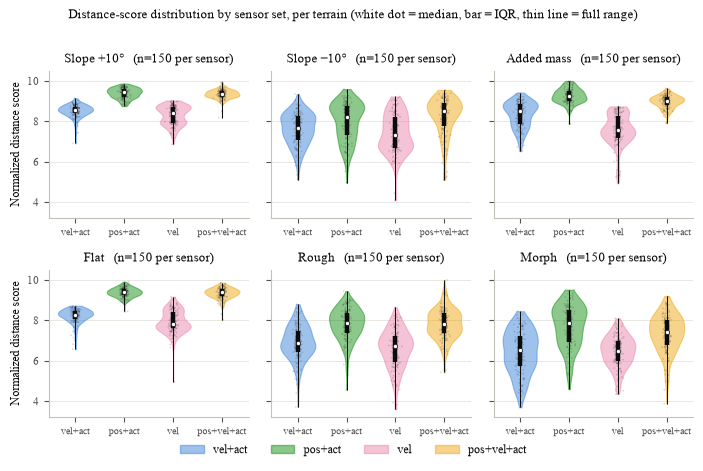

In [15]:
from matplotlib.patches import Patch

# Categorical palette validated for colour-vision deficiency on a white surface
# under the strict all-pairs gate (worst pair ΔE 13.0 protan, 19.6 normal
# vision). Keyed by sensor, so a hue follows its sensor set regardless of the
# order `local_prop` happens to list them in.
SERIES = {"vel_action": "#2a78d6", "pos_action": "#008300",
          "vel": "#e87ba4", "pos_vel_action": "#eda100"}
SLABEL = {"vel_action": "vel+act", "pos_action": "pos+act",
          "vel": "vel", "pos_vel_action": "pos+vel+act"}
TLABEL = {"flat": "Flat", "rough": "Rough", "morph": "Morph",
          "slope10": "Slope +10°", "slope_10": "Slope −10°", "mass1000": "Added mass"}
INK, INK2, GRID, BASE = "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"

terrains = list(terrain)
missing = [s for s in local_prop if s not in data[terrains[0]]]
assert not missing, f"not in data: {missing} -- available: {sorted(data[terrains[0]])}"

plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.edgecolor": BASE, "axes.linewidth": 0.8, "text.color": INK,
    "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "axes.titlesize": 9,
})

fig, axes = plt.subplots(2, 3, figsize=(7.16, 4.4), sharey=True)   # 7.16in = IEEE 2-col
rng = np.random.default_rng(0)

# Violins are not length-encoded, so fit the axis to the data rather than
# padding down to zero.
allv = [data[t][s] for t in terrains for s in local_prop]
YLO, YHI = min(v.min() for v in allv) - 0.4, max(v.max() for v in allv) + 0.5

for ax, t in zip(axes.ravel(), terrains):
    groups = [np.asarray(data[t][s], dtype=float) for s in local_prop]

    parts = ax.violinplot(groups, showextrema=False, widths=0.72)
    for body, s in zip(parts["bodies"], local_prop):
        body.set_facecolor(SERIES[s]); body.set_edgecolor(SERIES[s])
        body.set_alpha(0.45); body.set_linewidth(0.8)

    for i, g in enumerate(groups, start=1):
        ax.scatter(rng.normal(i, 0.045, size=g.size), g, s=1.5, color=INK,
                   alpha=0.16, edgecolors="none", zorder=3)
        q1, med, q3 = np.percentile(g, [25, 50, 75])
        ax.vlines(i, q1, q3, color=INK, lw=3.2, zorder=4)             # IQR
        ax.vlines(i, g.min(), g.max(), color=INK, lw=0.7, zorder=4)   # full range
        ax.scatter(i, med, s=9, color="white", zorder=5,
                   edgecolors=INK, linewidths=0.5)                    # median

    ax.set_title(f"{TLABEL.get(t, t)}   (n={groups[0].size} per sensor)", color=INK, pad=6)
    ax.set_xticks(range(1, len(local_prop) + 1))
    ax.set_xticklabels([SLABEL.get(s, s) for s in local_prop], fontsize=7.5)
    ax.set_ylim(YLO, YHI)
    ax.grid(True, axis="y", color=GRID, lw=0.6, alpha=0.9)
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

for ax in axes[:, 0]:
    ax.set_ylabel("Normalized distance score", fontsize=8.5)

fig.legend(handles=[Patch(facecolor=SERIES[s], alpha=0.45, edgecolor=SERIES[s],
                          label=SLABEL.get(s, s))
                    for s in local_prop],
           loc="lower center", ncol=len(local_prop), frameon=False, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.035))
fig.suptitle("Distance-score distribution by sensor set, per terrain "
             "(white dot = median, bar = IQR, thin line = full range)",
             fontsize=9, color=INK, y=1.005)
fig.tight_layout()
# fig.savefig("local_prop_distribution.pdf", bbox_inches="tight")
# fig.savefig("local_prop_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

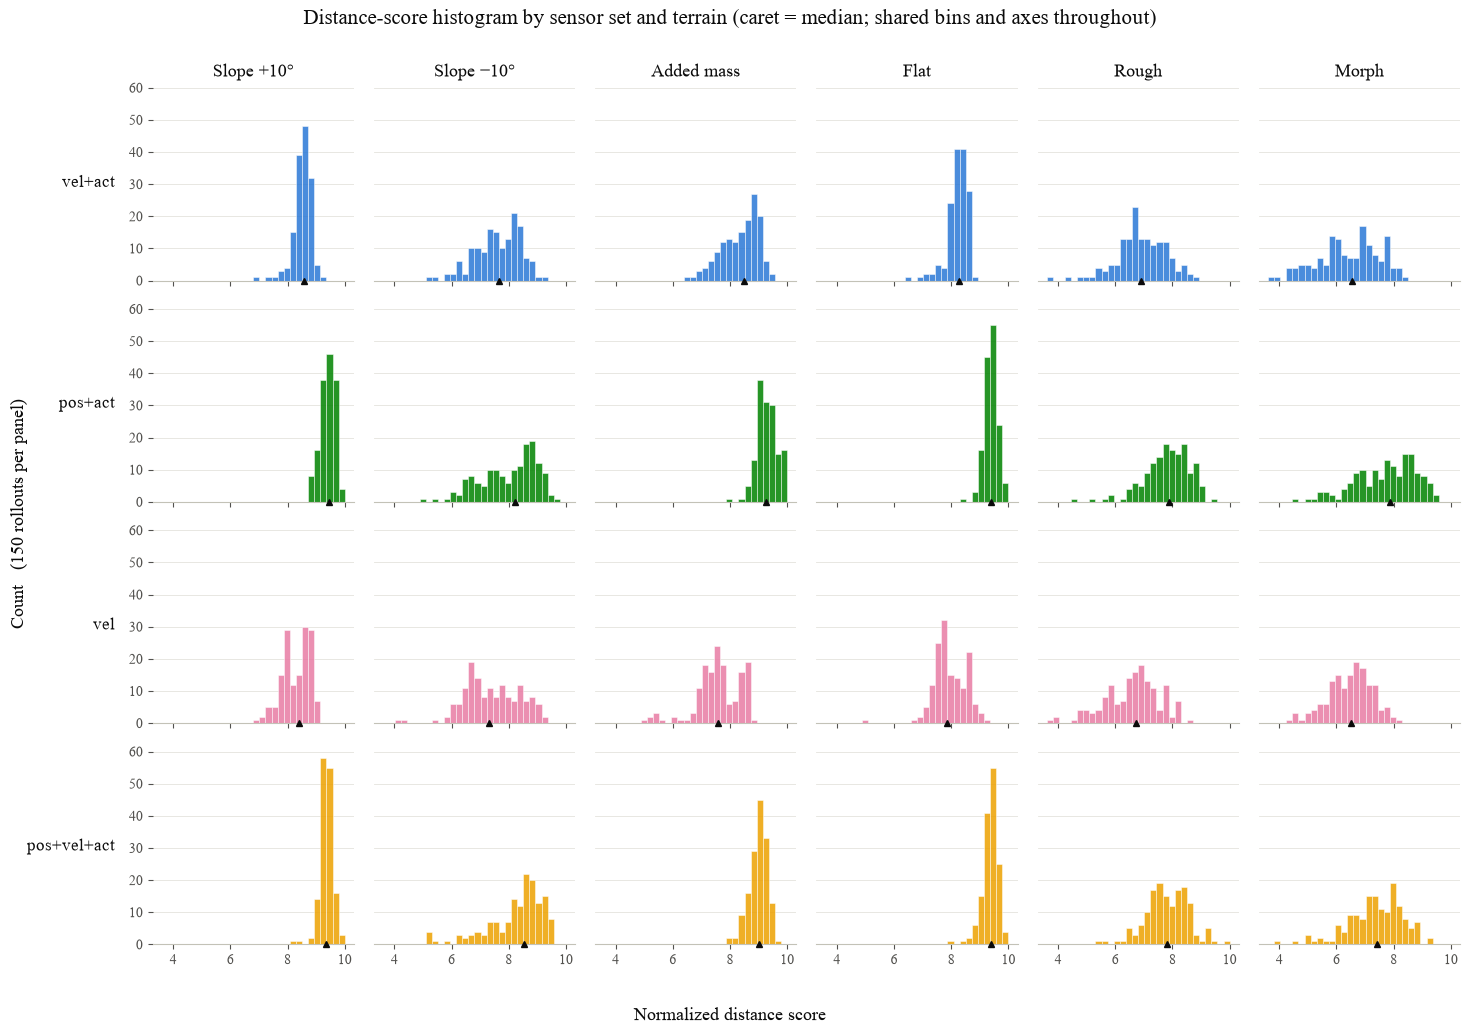

In [16]:
# Histogram view of the same data. Small multiples rather than 4 overlaid
# histograms: overlapping translucent fills go muddy, and faceting is the
# standard fix. Binned counts also invent no tails -- the long lower tail on
# flat/vel in the violin above is KDE smoothing over a single outlier, and here
# it shows as the one bar it actually is.
#
# Rows = sensor, cols = terrain, sharing one x-axis: stacking the 4 sensors
# under a common scale makes the within-terrain comparison a vertical read.

terrains = list(terrain)
groups = {(t, s): np.asarray(data[t][s], dtype=float)
          for t in terrains for s in local_prop}

# One shared set of bin edges so every panel's bars mean the same thing
edges = np.histogram_bin_edges(np.concatenate(list(groups.values())), bins=30)

fig, axes = plt.subplots(len(local_prop), len(terrains), figsize=(15, 10),
                         sharex=True, sharey=True)

for row, s in enumerate(local_prop):
    for col, t in enumerate(terrains):
        ax = axes[row, col]
        g = groups[(t, s)]
        # white bar edges give the surface gap between adjacent fills
        ax.hist(g, bins=edges, color=SERIES[s], alpha=0.85,
                edgecolor="white", linewidth=0.4)
        # median as a caret on the baseline. A full-height axvline out-shouts
        # the bars it annotates -- 24 heavy rules read as the subject of the
        # figure instead of the distributions.
        ax.plot([np.median(g)], [0], marker="^", ms=5, color=INK,
                clip_on=False, zorder=6)

        if row == 0:
            ax.set_title(TLABEL.get(t, t), color=INK, pad=6, fontsize=13)
        if col == 0:
            ax.set_ylabel(SLABEL.get(s, s), color=INK, fontsize=12, rotation=0,
                          ha="right", va="center", labelpad=10)
        ax.grid(True, axis="y", color=GRID, lw=0.6, alpha=0.9)
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=10, left=(col == 0))   # sharey: ticks once
        for sp in ("top", "right", "left"):
            ax.spines[sp].set_visible(False)

fig.supxlabel("Normalized distance score", fontsize=13, color=INK, y=-0.01)
fig.supylabel("Count   (150 rollouts per panel)", fontsize=13, color=INK, x=0.02)
fig.suptitle("Distance-score histogram by sensor set and terrain "
             "(caret = median; shared bins and axes throughout)",
             fontsize=15, color=INK, y=1.005)
fig.tight_layout()
# fig.savefig("local_prop_histogram.pdf", bbox_inches="tight")
# fig.savefig("local_prop_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

## P value test

In [17]:
from itertools import combinations
from scipy import stats

# Welch two-sample z-test, H0: mu1 - mu2 = 0. n=150 per group, so the normal
# approximation is fine; variance is estimated from the sample (ddof=1).
#
# norm.sf(|z|), NOT 1 - norm.cdf(|z|): cdf(33) rounds to 1.0 in float64, so the
# subtraction underflows to exactly 0 for 20 of these 36 pairs. sf computes the
# upper tail directly and keeps p down to ~1e-238.

Z, p_val = {}, {}
for t in terrains:
    Z[t], p_val[t] = {}, {}
    for sen1 in local_prop:
        Z[t][sen1], p_val[t][sen1] = {}, {}
        for sen2 in local_prop:
            a, b = data[t][sen1], data[t][sen2]
            se = np.sqrt(a.var(ddof=1) / a.size + b.var(ddof=1) / b.size)
            z = 0.0 if se == 0 else (a.mean() - b.mean()) / se
            Z[t][sen1][sen2] = z
            p_val[t][sen1][sen2] = float(2 * stats.norm.sf(abs(z)))

# Holm-Bonferroni over the whole family. Only the 6 distinct pairs per terrain
# count: the diagonal is trivially p=1 and (j,i) merely flips the sign of z, so
# counting them would inflate m to 96 and over-correct.
PAIRS = list(combinations(local_prop, 2))
fam = [(t, s1, s2) for t in terrains for s1, s2 in PAIRS]
m = len(fam)

p_holm, running = {}, 0.0
for rank, k in enumerate(sorted(fam, key=lambda k: p_val[k[0]][k[1]][k[2]])):
    running = max(running, min(1.0, p_val[k[0]][k[1]][k[2]] * (m - rank)))
    p_holm[k] = running        # max enforces monotonicity along the ranking

print(f"family size m = {m}")
print(f"raw  p<0.05: {sum(p_val[t][a][b] < 0.05 for t, a, b in fam)} / {m}")
print(f"Holm p<0.05: {sum(p_holm[k] < 0.05 for k in fam)} / {m}")
print("\nnot significant after Holm:")
for k in sorted(fam, key=lambda k: -p_holm[k]):
    if p_holm[k] >= 0.05:
        print(f"  {k[0]:>9}  {k[1]:>15} vs {k[2]:<15} "
              f"raw={p_val[k[0]][k[1]][k[2]]:.4f}  holm={p_holm[k]:.4f}")

family size m = 36
raw  p<0.05: 32 / 36
Holm p<0.05: 30 / 36

not significant after Holm:
      rough       pos_action vs pos_vel_action  raw=0.9024  holm=1.0000
      morph       vel_action vs vel             raw=0.6781  holm=1.0000
       flat       pos_action vs pos_vel_action  raw=0.2083  holm=0.6249
    slope10       pos_action vs pos_vel_action  raw=0.0948  holm=0.3792
   slope_10       vel_action vs vel             raw=0.0390  holm=0.1949
   slope_10       pos_action vs pos_vel_action  raw=0.0185  holm=0.1108


In [18]:
data['flat'].keys()

dict_keys(['vel', 'pos_action', 'vel_action', 'pos_vel_action', 'vel_imu', 'pos_action_imu', 'vel_action_imu', 'pos_vel_action_imu', 'vel_fc', 'action_fc', 'vel_action_fc', 'pos_vel_action_fc', 'vel_imu_fc', 'pos_vel_imu_fc', 'action_imu_fc', 'vel_action_imu_fc', 'pos_vel_action_imu_fc'])

In [19]:
p_val['flat']['vel']['pos_vel_action']   # 2.56e-162 -- was 0.0 under the cdf route

2.554458353829646e-162

## Significance heatmaps

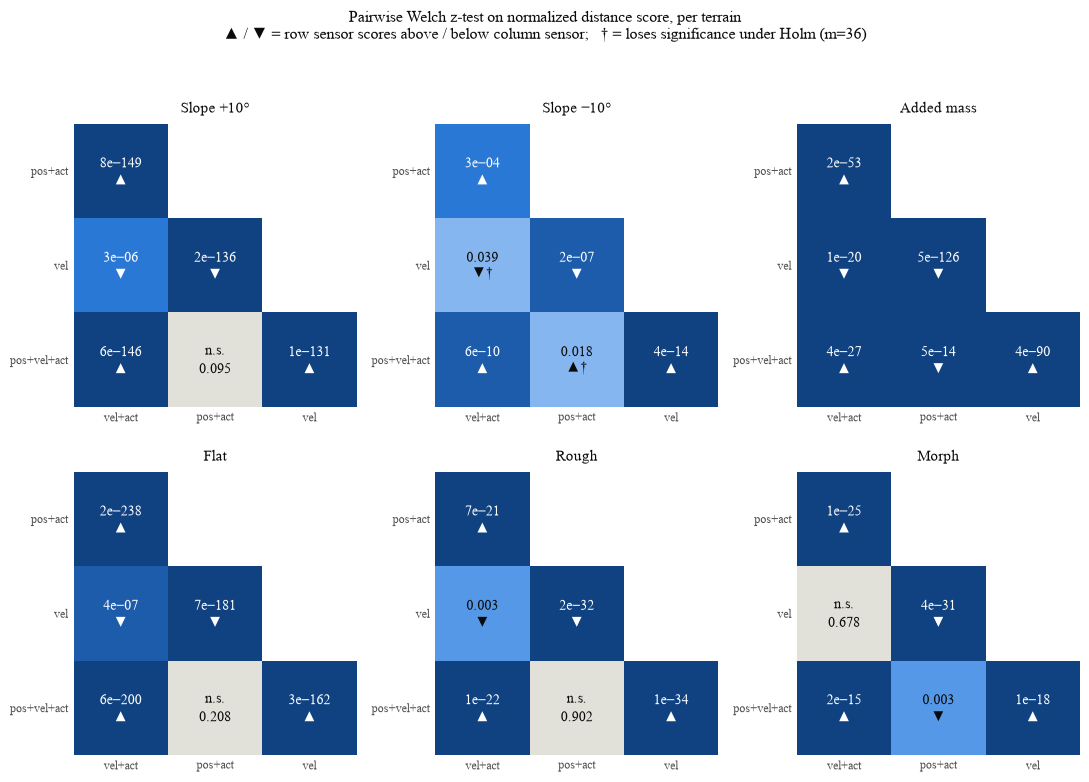

In [20]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Significance scale shared by both heatmaps below.
#
# p-values span 238 orders of magnitude (1.7e-238 .. 0.90) and 32/36 pairs are
# significant, so a continuous -log10(p) ramp would be a near-solid dark block
# -- the information is in *which four pairs are not*. Bin instead, onto an
# ordinal single-hue blue ramp. "n.s." is grey, not a lighter blue: it's a
# different conclusion, not less of the same one -- and it still carries a
# text label, so no cell depends on colour alone.

SIG_EDGES  = [1e-12, 1e-6, 1e-3, 1e-2, 5e-2]
SIG_COLORS = ["#104281", "#1c5cab", "#2a78d6", "#5598e7", "#86b6ef", "#e1e0d9"]
SIG_TEXTC  = ["white", "white", "white", INK, INK, INK]
SIG_LABELS = ["p < 1e−12", "p < 1e−6", "p < 1e−3", "p < 0.01", "p < 0.05",
              "n.s.  (p ≥ 0.05)"]
CMAP = ListedColormap(SIG_COLORS)
CMAP.set_bad("none")            # masked upper triangle drops to the page


def sig_bin(p):
    return int(np.searchsorted(SIG_EDGES, p, side="right"))


def cell_text(t, s1, s2):
    p = p_val[t][s1][s2]
    b = sig_bin(p)
    if b == len(SIG_COLORS) - 1:
        return f"n.s.\n{p:.3f}", b
    ptxt = f"{p:.3f}" if p >= 1e-3 else f"{p:.0e}".replace("e-", "e−")
    arrow = "▲" if data[t][s1].mean() > data[t][s2].mean() else "▼"
    holm = p_holm.get((t, s1, s2), p_holm.get((t, s2, s1)))
    # return f"{ptxt}\n{'' if holm < 0.05 else '†'}", b
    return f"{ptxt}\n{arrow}{'' if holm < 0.05 else '†'}", b


def sig_legend(fig, y):
    fig.legend(handles=[Patch(facecolor=c, edgecolor=BASE, lw=0.5, label=l)
                        for c, l in zip(SIG_COLORS, SIG_LABELS)],
               loc="lower center", ncol=len(SIG_COLORS), frameon=False,
               fontsize=9, bbox_to_anchor=(0.5, y), handlelength=1.4,
               columnspacing=1.5)


plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"],
    "text.color": INK, "axes.labelcolor": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.edgecolor": BASE,
})

# ---- Per-terrain matrices. Lower triangle only: the matrix is symmetric in p,
# ---- and the diagonal is trivially p=1. No separator grid or spines -- the
# ---- fills are the figure, and each cell's own label keeps boundaries readable.
n = len(local_prop)
fig, axes = plt.subplots(2, 3, figsize=(11, 7.6))

for ax, t in zip(axes.ravel(), terrains):
    M = np.full((n, n), np.nan)
    for i, s1 in enumerate(local_prop):
        for j, s2 in enumerate(local_prop):
            if i > j:
                M[i, j] = sig_bin(p_val[t][s1][s2])
    ax.imshow(M, cmap=CMAP, vmin=-0.5, vmax=len(SIG_COLORS) - 0.5)

    for i, s1 in enumerate(local_prop):
        for j, s2 in enumerate(local_prop):
            if i > j:
                txt, b = cell_text(t, s1, s2)
                ax.text(j, i, txt, ha="center", va="center", fontsize=10,
                        color=SIG_TEXTC[b], linespacing=1.35)

    ax.set_xticks(range(n - 1))
    ax.set_xticklabels([SLABEL[s] for s in local_prop[:-1]], fontsize=8.5)
    ax.set_yticks(range(1, n))
    ax.set_yticklabels([SLABEL[s] for s in local_prop[1:]], fontsize=8.5)
    ax.set_xlim(-0.5, n - 1.5)
    ax.set_ylim(n - 0.5, 0.5)          # crop the empty row/col the triangle leaves
    ax.tick_params(length=0, pad=4)
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(TLABEL.get(t, t), fontsize=11, pad=8)

# sig_legend(fig, -0.02)
fig.suptitle("Pairwise Welch z-test on normalized distance score, per terrain\n"
             "▲ / ▼ = row sensor scores above / below column sensor;   "
             "† = loses significance under Holm (m=36)",
             fontsize=11.5, y=1.03)
fig.tight_layout()
# fig.savefig("local_prop_pvalue_per_terrain.pdf", bbox_inches="tight")
# fig.savefig("local_prop_pvalue_per_terrain.png", dpi=300, bbox_inches="tight")
plt.show()

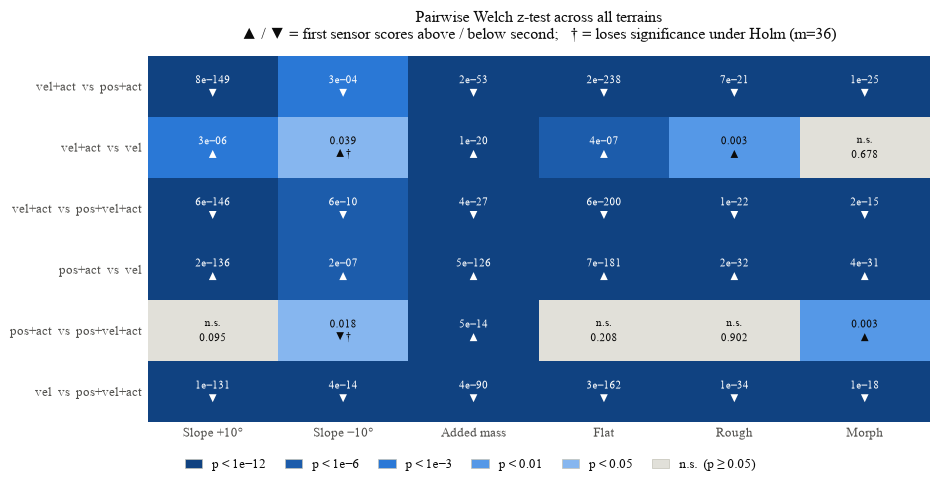

In [21]:
# ---- All terrains in one matrix: rows = the 6 distinct sensor pairs, cols =
# ---- terrain. Same scale as above. This is the overview -- a pair that is
# ---- indistinguishable across several terrains reads as a grey run in its row.

fig, ax = plt.subplots(figsize=(9.5, 4.6))

M = np.array([[sig_bin(p_val[t][s1][s2]) for t in terrains]
              for s1, s2 in PAIRS], dtype=float)
ax.imshow(M, cmap=CMAP, vmin=-0.5, vmax=len(SIG_COLORS) - 0.5, aspect="auto")

for r, (s1, s2) in enumerate(PAIRS):
    for c, t in enumerate(terrains):
        txt, b = cell_text(t, s1, s2)
        ax.text(c, r, txt, ha="center", va="center", fontsize=8,
                color=SIG_TEXTC[b], linespacing=1.35)

ax.set_xticks(range(len(terrains)))
ax.set_xticklabels([TLABEL.get(t, t) for t in terrains], fontsize=9.5)
ax.set_yticks(range(len(PAIRS)))
ax.set_yticklabels([f"{SLABEL[a]}  vs  {SLABEL[b]}" for a, b in PAIRS], fontsize=9.5)
ax.tick_params(length=0, pad=4)
for sp in ax.spines.values():
    sp.set_visible(False)

sig_legend(fig, -0.06)
ax.set_title("Pairwise Welch z-test across all terrains\n"
             "▲ / ▼ = first sensor scores above / below second;   "
             "† = loses significance under Holm (m=36)", fontsize=11.5, pad=12)
fig.tight_layout()
# fig.savefig("local_prop_pvalue_all_terrain.pdf", bbox_inches="tight")
# fig.savefig("local_prop_pvalue_all_terrain.png", dpi=300, bbox_inches="tight")
plt.show()

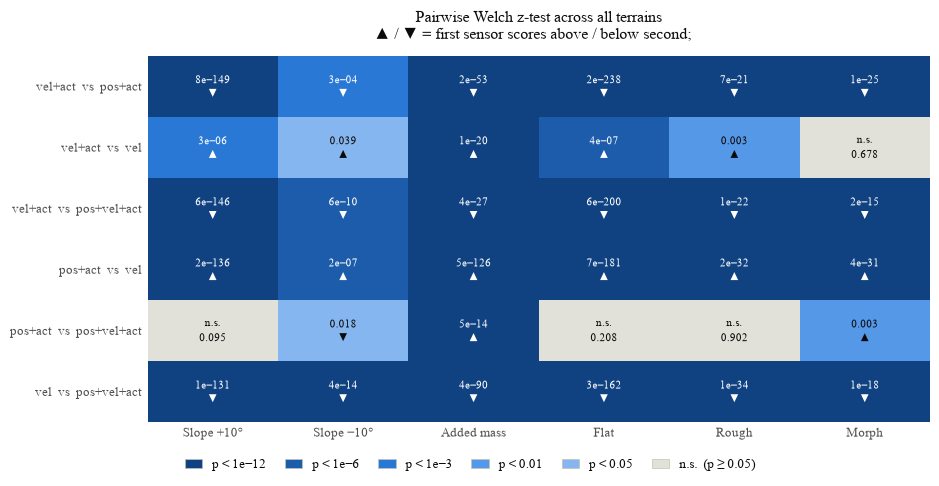

In [27]:
def cell_text(t, s1, s2):
    p = p_val[t][s1][s2]
    b = sig_bin(p)
    if b == len(SIG_COLORS) - 1:
        return f"n.s.\n{p:.3f}", b
    ptxt = f"{p:.3f}" if p >= 1e-3 else f"{p:.0e}".replace("e-", "e−")
    arrow = "▲" if data[t][s1].mean() > data[t][s2].mean() else "▼"
    # return f"{ptxt}\n{'' if holm < 0.05 else '†'}", b
    return f"{ptxt}\n{arrow}", b

fig, ax = plt.subplots(figsize=(9.5, 4.6))

M = np.array([[sig_bin(p_val[t][s1][s2]) for t in terrains]
              for s1, s2 in PAIRS], dtype=float)
ax.imshow(M, cmap=CMAP, vmin=-0.5, vmax=len(SIG_COLORS) - 0.5, aspect="auto")

for r, (s1, s2) in enumerate(PAIRS):
    for c, t in enumerate(terrains):
        txt, b = cell_text(t, s1, s2)
        ax.text(c, r, txt, ha="center", va="center", fontsize=8,
                color=SIG_TEXTC[b], linespacing=1.35)

ax.set_xticks(range(len(terrains)))
ax.set_xticklabels([TLABEL.get(t, t) for t in terrains], fontsize=9.5)
ax.set_yticks(range(len(PAIRS)))
ax.set_yticklabels([f"{SLABEL[a]}  vs  {SLABEL[b]}" for a, b in PAIRS], fontsize=9.5)
ax.tick_params(length=0, pad=4)
for sp in ax.spines.values():
    sp.set_visible(False)

sig_legend(fig, -0.06)
ax.set_title("Pairwise Welch z-test across all terrains\n"
             "▲ / ▼ = first sensor scores above / below second;   ",
             fontsize=11.5, pad=12)
fig.tight_layout()
# fig.savefig("local_prop_pvalue_all_terrain.pdf", bbox_inches="tight")
fig.savefig("local_prop_pvalue_all_terrain.png", dpi=300, bbox_inches="tight")
plt.show()

## Z-value heatmaps

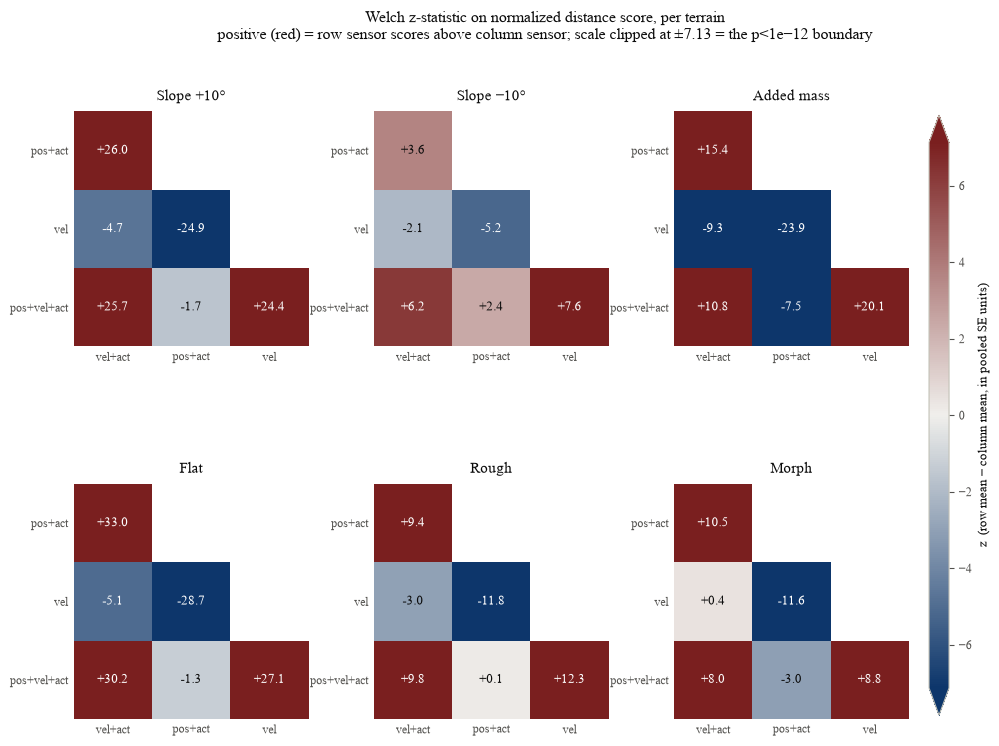

In [22]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

# z is signed and continuous (not the p-value's 238-orders-of-magnitude spread),
# so it gets a diverging scale rather than bins: blue <-> red, neutral gray at
# z=0, per the diverging-pair convention used elsewhere in this project.
#
# Clipped at +/-7.13 -- the |z| that corresponds to the p<1e-12 boundary in the
# significance heatmaps above -- so "fully saturated here" means the same thing
# as "darkest cell there". Text always shows the exact value; the color only
# needs to place it on the map.
#
# Same lower-triangle layout as the significance heatmap (i > j in local_prop
# order), so the two figures read side by side cell-for-cell. z flips sign
# under (s1,s2) -> (s2,s1), so unlike p this pick of triangle is a real choice,
# not a redundant half of a symmetric matrix -- it's the same choice already
# made for the p-value cells, kept consistent here. Sign of the number carries
# direction, so no arrow annotation is needed.

Z_CLIP = 7.13
ZCMAP = LinearSegmentedColormap.from_list("z_diverge", ["#0d366b", "#f0efec", "#7a1f1f"])
ZCMAP.set_bad("none")           # masked upper triangle drops to the page
ZNORM = TwoSlopeNorm(vmin=-Z_CLIP, vcenter=0.0, vmax=Z_CLIP)


def z_textcolor(z):
    return "white" if abs(z) > Z_CLIP * 0.55 else INK


n = len(local_prop)
fig, axes = plt.subplots(2, 3, figsize=(11, 7.6))

for ax, t in zip(axes.ravel(), terrains):
    M = np.full((n, n), np.nan)
    for i, s1 in enumerate(local_prop):
        for j, s2 in enumerate(local_prop):
            if i > j:
                M[i, j] = Z[t][s1][s2]
    im = ax.imshow(M, cmap=ZCMAP, norm=ZNORM)

    for i, s1 in enumerate(local_prop):
        for j, s2 in enumerate(local_prop):
            if i > j:
                z = Z[t][s1][s2]
                ax.text(j, i, f"{z:+.1f}", ha="center", va="center", fontsize=9,
                        color=z_textcolor(z))

    ax.set_xticks(range(n - 1))
    ax.set_xticklabels([SLABEL[s] for s in local_prop[:-1]], fontsize=8.5)
    ax.set_yticks(range(1, n))
    ax.set_yticklabels([SLABEL[s] for s in local_prop[1:]], fontsize=8.5)
    ax.set_xlim(-0.5, n - 1.5)
    ax.set_ylim(n - 0.5, 0.5)          # crop the empty row/col the triangle leaves
    ax.tick_params(length=0, pad=4)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(TLABEL.get(t, t), fontsize=11, pad=8)

fig.tight_layout()
cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02, extend="both", aspect=30)
cbar.set_label("z  (row mean − column mean, in pooled SE units)", fontsize=9.5)
cbar.ax.tick_params(labelsize=8.5)

fig.suptitle("Welch z-statistic on normalized distance score, per terrain\n"
             "positive (red) = row sensor scores above column sensor; "
             f"scale clipped at ±{Z_CLIP:.2f} = the p<1e−12 boundary",
             fontsize=11.5, y=1.03)
# fig.savefig("local_prop_zvalue_per_terrain.pdf", bbox_inches="tight")
# fig.savefig("local_prop_zvalue_per_terrain.png", dpi=300, bbox_inches="tight")
plt.show()

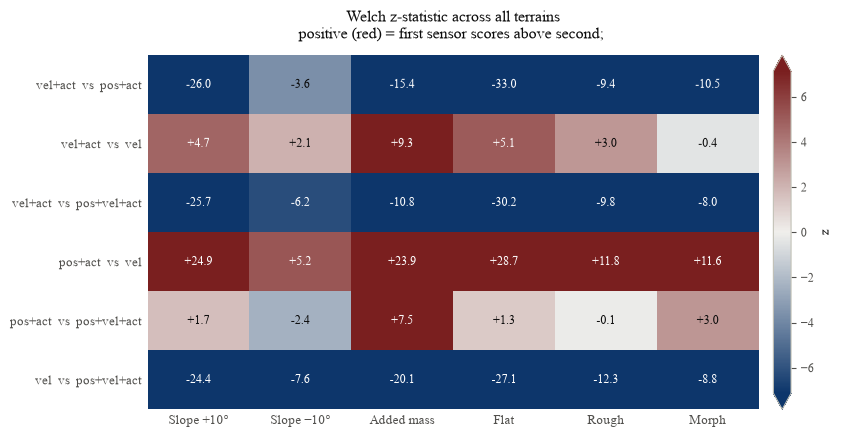

In [25]:
# ---- All terrains overview: same PAIRS ordering as the significance heatmap,
# ---- so the two figures line up row for row. Reading "vel+act vs pos+act" as
# ---- blue across every terrain here is the same fact as "row loses" in the
# ---- significance heatmap, just with effect size attached instead of a bin.

fig, ax = plt.subplots(figsize=(9.5, 4.6))

M = np.array([[Z[t][s1][s2] for t in terrains] for s1, s2 in PAIRS], dtype=float)
im = ax.imshow(M, cmap=ZCMAP, norm=ZNORM, aspect="auto")

for r, (s1, s2) in enumerate(PAIRS):
    for c, t in enumerate(terrains):
        z = M[r, c]
        ax.text(c, r, f"{z:+.1f}", ha="center", va="center", fontsize=8.5,
                color=z_textcolor(z))

ax.set_xticks(range(len(terrains)))
ax.set_xticklabels([TLABEL.get(t, t) for t in terrains], fontsize=9.5)
ax.set_yticks(range(len(PAIRS)))
ax.set_yticklabels([f"{SLABEL[a]}  vs  {SLABEL[b]}" for a, b in PAIRS], fontsize=9.5)
ax.tick_params(length=0, pad=4)
for sp in ax.spines.values():
    sp.set_visible(False)

cbar = fig.colorbar(im, ax=ax, pad=0.02, extend="both")
# cbar.set_label("z  (first sensor mean − second sensor mean)", fontsize=9.5)
cbar.set_label("z", fontsize=9.5)

cbar.ax.tick_params(labelsize=8.5)

# ax.set_title("Welch z-statistic across all terrains\n"
#              "positive (red) = first sensor scores above second; "
#              f"scale clipped at ±{Z_CLIP:.2f} = the p<1e−12 boundary",
#              fontsize=11.5, pad=12)
ax.set_title("Welch z-statistic across all terrains\n"
             "positive (red) = first sensor scores above second; ",
             fontsize=11.5, pad=12)
# fig.savefig("local_prop_zvalue_all_terrain.pdf", bbox_inches="tight")
fig.savefig("local_prop_zvalue_all_terrain.png", dpi=300, bbox_inches="tight")
plt.show()